In [2]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch 
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt



In [13]:
torch.manual_seed(42)

In [17]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


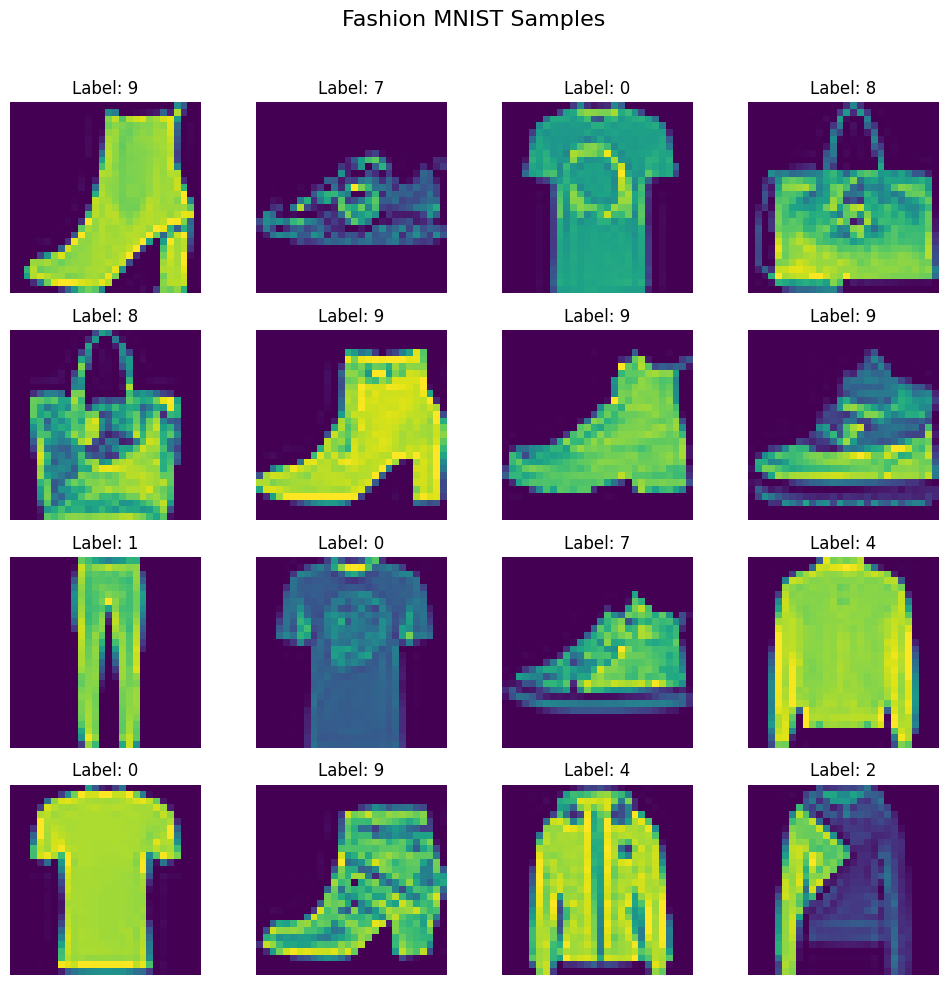

In [23]:
fig,axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle('Fashion MNIST Samples',fontsize=16)
for i,ax in enumerate(axes.flatten()):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Label: {df.iloc[i,0]}')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [25]:
x = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [27]:
x_train = x_train/255.0
x_test = x_test/255.0

In [28]:
x_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]], shape=(4800, 784))

In [31]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels,dtype=torch.long)
    def __len__(self):
        return len(self.features)
    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [32]:
train_dataset = CustomDataset(x_train,y_train)
len(train_dataset)

4800

In [33]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [36]:
test_dataset = CustomDataset(x_test,y_test)
len(test_dataset)

1200

In [39]:
train_Loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_Loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

In [41]:
class Mynn(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self,x):
        return self.model(x)
    
    

In [43]:
epochs = 100
learning_rate = 0.01

In [45]:
model = Mynn(x_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [51]:
len(train_Loader)

75

In [52]:
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features,batch_labels in train_Loader:
        outputs = model(batch_features)
        loss = criterion(outputs,batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_Loader):.4f}')

Epoch 1/100, Loss: 0.0636
Epoch 2/100, Loss: 0.0722
Epoch 3/100, Loss: 0.0815
Epoch 4/100, Loss: 0.0629
Epoch 5/100, Loss: 0.0641
Epoch 6/100, Loss: 0.0768
Epoch 7/100, Loss: 0.0593
Epoch 8/100, Loss: 0.0893
Epoch 9/100, Loss: 0.0603
Epoch 10/100, Loss: 0.0860
Epoch 11/100, Loss: 0.0612
Epoch 12/100, Loss: 0.0632
Epoch 13/100, Loss: 0.0569
Epoch 14/100, Loss: 0.0584
Epoch 15/100, Loss: 0.0679
Epoch 16/100, Loss: 0.0680
Epoch 17/100, Loss: 0.0585
Epoch 18/100, Loss: 0.0611
Epoch 19/100, Loss: 0.0556
Epoch 20/100, Loss: 0.0551
Epoch 21/100, Loss: 0.0569
Epoch 22/100, Loss: 0.0700
Epoch 23/100, Loss: 0.0539
Epoch 24/100, Loss: 0.0496
Epoch 25/100, Loss: 0.0553
Epoch 26/100, Loss: 0.0522
Epoch 27/100, Loss: 0.0487
Epoch 28/100, Loss: 0.0525
Epoch 29/100, Loss: 0.0495
Epoch 30/100, Loss: 0.0462
Epoch 31/100, Loss: 0.0691
Epoch 32/100, Loss: 0.0477
Epoch 33/100, Loss: 0.0474
Epoch 34/100, Loss: 0.0728
Epoch 35/100, Loss: 0.0482
Epoch 36/100, Loss: 0.0481
Epoch 37/100, Loss: 0.0462
Epoch 38/1

In [53]:
model.eval()


Mynn(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
total = 0
correct = 0
with torch.no_grad():
    